<a href="https://colab.research.google.com/github/Doan-Truc/Doan-Truc/blob/main/visualize_prethesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 46.9 MB/s eta 0:00:00


In [ ]:
pip install pandas matplotlib

ID1-run1

Loaded EEG data with 22 channels and 12288 samples.
Loaded Session Setup: {'Action.R': 2, 'Action.C': 2, 'Action.RH': 4, 'Action.LH': 4, 'Action.RF': 4, 'Action.LF': 4, 'Action.PTL': 0, 'Action.PTR': 0, 'Action.B': 0, 'Action.OCM': 0, 'Action.NH': 0, 'Action.SH': 0, 'Action.RHOC': 4, 'Action.LHOC': 4, 'Action.T': 4, 'Action.A': 4, 'Action.M': 4}
Loaded Action Labels: ['Rest', 'Cue', 'Right Hand', 'Rest', 'Cue', 'Left Hand', 'Rest', 'Cue', 'Right Foot', 'Rest', 'Cue', 'Left Foot', 'Rest', 'Cue', 'Right Hand', 'Rest', 'Cue', 'Left Hand', 'Rest', 'Cue', 'Right Foot', 'Rest', 'Cue', 'Left Foot', 'Rest', 'Cue', 'Right Hand', 'Rest', 'Cue', 'Left Hand', 'Rest', 'Cue', 'Right Foot', 'Rest', 'Cue', 'Left Foot']
Loaded Event Timestamps: [352, 1344, 2656, 3456, 4608, 5696, 7552, 9568, 11616]


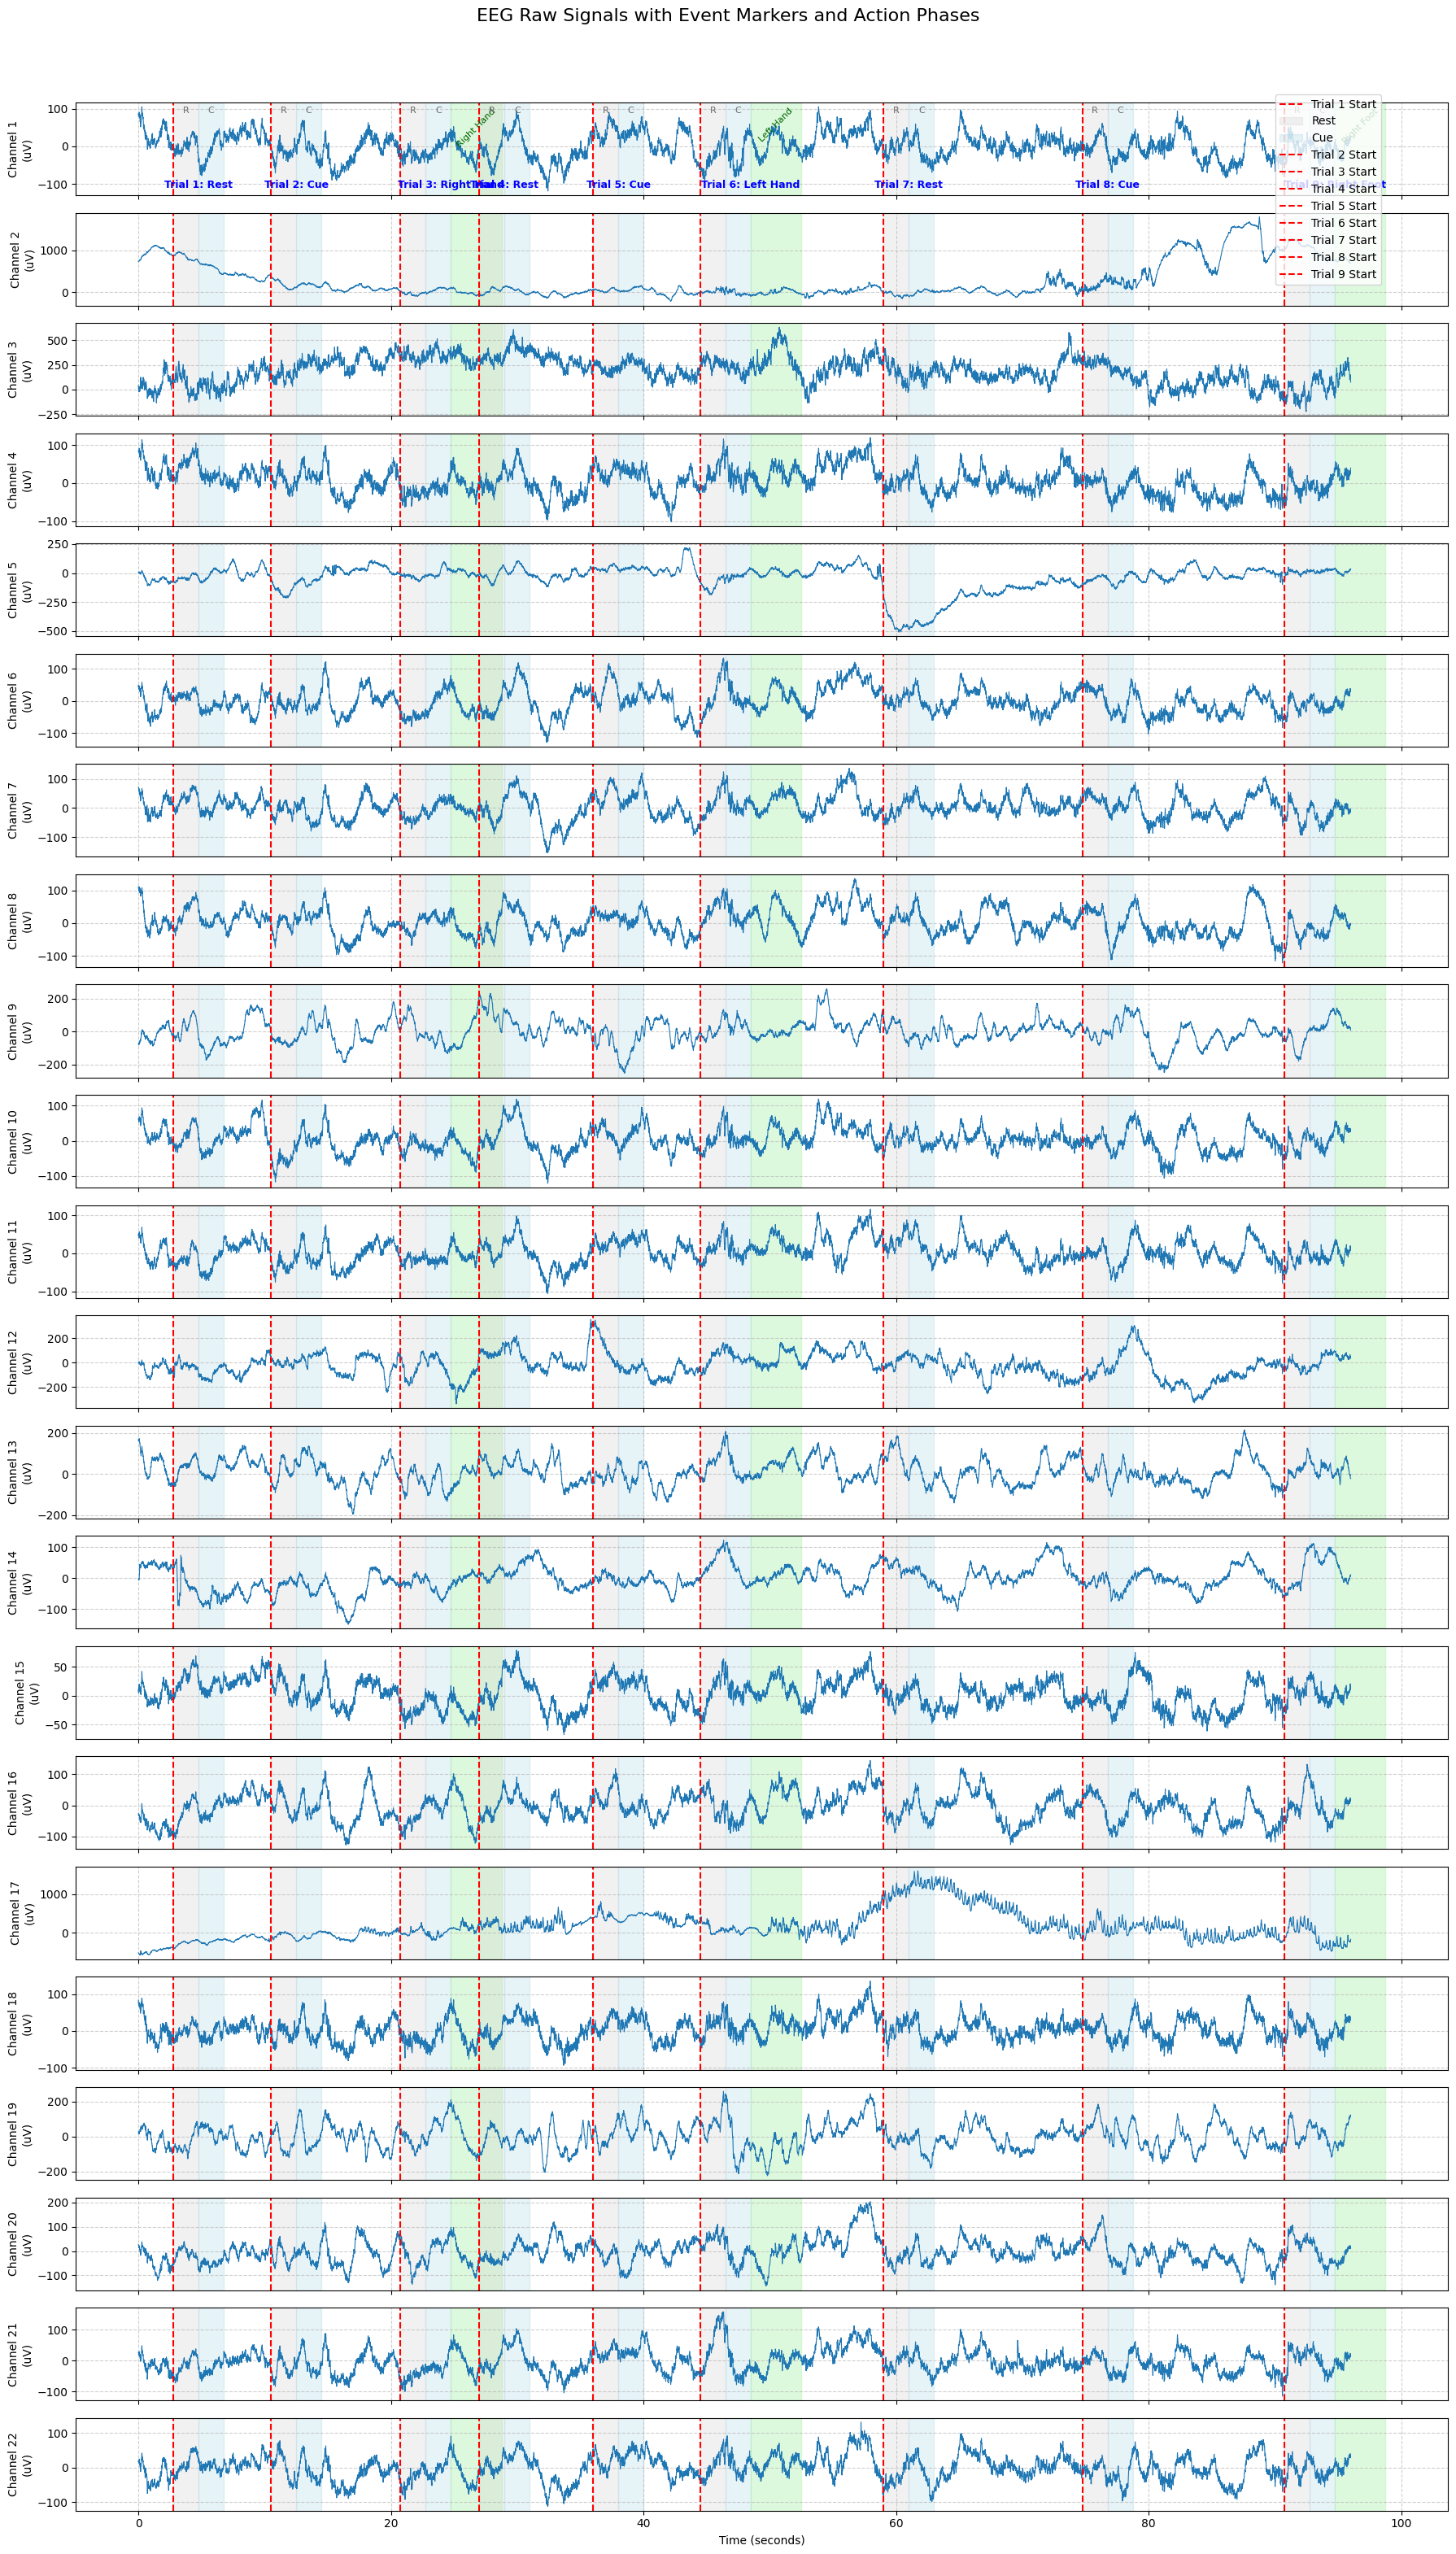

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import numpy as np

def visualize_eeg_data(raw_signal_path, session_setup_path, action_label_path, event_timestamp_path, sfreq=128):
    """
    Visualizes EEG data from provided files with event timestamps and action labels.

    Args:
        raw_signal_path (str): Path to the Raw Signals .csv file.
        session_setup_path (str): Path to the Session setup .json file.
        action_label_path (str): Path to the Action label .txt file.
        event_timestamp_path (str): Path to the Event timestamp .txt file.
        sfreq (int): Sampling frequency of the EEG data (Hz). Default is 128 Hz.
    """

    # 1. Load Raw EEG Signals
    try:
        eeg_df = pd.read_csv(raw_signal_path)
        # Giả sử cột đầu tiên là thời gian hoặc chỉ số, và các cột còn lại là kênh EEG.
        # Nếu cột đầu tiên là chỉ số, chúng ta có thể loại bỏ nó hoặc sử dụng làm index.
        # Để đơn giản, ta giả định tất cả các cột đều là kênh EEG.
        # Nếu có cột 'Time' hoặc 'Sample', hãy loại bỏ nó hoặc đặt làm index
        if 'Time' in eeg_df.columns:
            eeg_df = eeg_df.drop(columns=['Time'])
        if 'Sample' in eeg_df.columns:
            eeg_df = eeg_df.drop(columns=['Sample'])

        # Đổi tên cột để dễ đọc hơn nếu tên cột là số hoặc không chuẩn
        # Nếu các cột đã là 'Channel_1', 'Channel_2', ... thì không cần đổi
        num_channels = eeg_df.shape[1]
        channel_names = [f'Channel {i+1}' for i in range(num_channels)]
        eeg_df.columns = channel_names

        print(f"Loaded EEG data with {num_channels} channels and {len(eeg_df)} samples.")

    except FileNotFoundError:
        print(f"Error: Raw Signals file not found at {raw_signal_path}")
        return
    except Exception as e:
        print(f"Error loading Raw Signals CSV: {e}")
        return

    # 2. Load Session Setup (duration of actions)
    try:
        with open(session_setup_path, 'r') as f:
            session_setup = json.load(f)
        duration_info = session_setup.get('duration', {})
        print(f"Loaded Session Setup: {duration_info}")
    except FileNotFoundError:
        print(f"Error: Session setup file not found at {session_setup_path}")
        return
    except json.JSONDecodeError as e:
        print(f"Error decoding Session setup JSON: {e}")
        return

    # 3. Load Action Labels
    try:
        with open(action_label_path, 'r') as f:
            action_labels_raw = f.read().splitlines()
        # Chuyển đổi nhãn từ số sang tên hành động nếu có mapping
        # Giả định mapping: 1->R, 2->C, 3->RH, 4->LH, 5->RF, 6->LF (dựa trên Run1_Action label.txt và Run1_Session setup.json)
        # Sẽ cần điều chỉnh mapping này nếu các nhãn số đại diện cho các hành động khác.
        label_mapping = {
            '1': 'Rest', # Dựa vào Run1_Session setup.json (Action.R)
            '2': 'Cue',  # Dựa vào Run1_Session setup.json (Action.C)
            '3': 'Right Hand', # Dựa vào Run1_Session setup.json (Action.RH)
            '4': 'Left Hand',  # Dựa vào Run1_Session setup.json (Action.LH)
            '5': 'Right Foot', # Dựa vào Run1_Session setup.json (Action.RF)
            '6': 'Left Foot'   # Dựa vào Run1_Session setup.json (Action.LF)
        }
        action_labels = [label_mapping.get(label.strip(), f'Unknown ({label.strip()})') for label in action_labels_raw if label.strip()]
        print(f"Loaded Action Labels: {action_labels}")
    except FileNotFoundError:
        print(f"Error: Action label file not found at {action_label_path}")
        return

    # 4. Load Event Timestamps
    try:
        with open(event_timestamp_path, 'r') as f:
            event_timestamps_raw = f.read().splitlines()
        event_timestamps = [int(ts.strip()) for ts in event_timestamps_raw if ts.strip()]
        print(f"Loaded Event Timestamps: {event_timestamps}")
    except FileNotFoundError:
        print(f"Error: Event timestamp file not found at {event_timestamp_path}")
        return

    # Create time array
    time = np.arange(len(eeg_df)) / sfreq

    # Visualize the data
    fig, axes = plt.subplots(nrows=num_channels, ncols=1, figsize=(18, num_channels * 1.5), sharex=True)
    if num_channels == 1: # Handle case with only one channel (axes will not be an array)
        axes = [axes]

    # Define phase durations in seconds based on your problem description and JSON
    # Assuming "Action.R" is Rest, "Action.C" is Cue, and others are Actions
    rest_duration_sec = duration_info.get('Action.R', 0)
    cue_duration_sec = duration_info.get('Action.C', 0)
    # The actual 'Action' phase duration is variable based on the specific action type (RH, LH, RF, LF)
    # For visualization, we'll use the duration of the *specific* action label.

    # Iterate through each channel and plot
    for i, channel_name in enumerate(channel_names):
        axes[i].plot(time, eeg_df[channel_name], lw=0.8)
        axes[i].set_ylabel(f'{channel_name}\n(uV)')
        axes[i].grid(True, linestyle='--', alpha=0.6)

        # Add event markers and action phase highlights
        for j, timestamp_sample in enumerate(event_timestamps):
            event_time = timestamp_sample / sfreq
            # Draw vertical line for event start
            axes[i].axvline(event_time, color='r', linestyle='--', lw=1.5, label=f'Trial {j+1} Start' if i == 0 else "")

            # Highlight phases (Rest, Cue, Action)
            if j < len(action_labels):
                current_action_label = action_labels[j]

                # Determine the duration of the "Action" phase for the current label
                action_phase_duration_sec = 0
                if current_action_label == 'Right Hand':
                    action_phase_duration_sec = duration_info.get('Action.RH', 0)
                elif current_action_label == 'Left Hand':
                    action_phase_duration_sec = duration_info.get('Action.LH', 0)
                elif current_action_label == 'Right Foot':
                    action_phase_duration_sec = duration_info.get('Action.RF', 0)
                elif current_action_label == 'Left Foot':
                    action_phase_duration_sec = duration_info.get('Action.LF', 0)
                # Add more conditions for other action types if they exist in your data

                # Plot Rest phase
                if rest_duration_sec > 0:
                    axes[i].axvspan(event_time, event_time + rest_duration_sec,
                                    color='lightgray', alpha=0.3, label='Rest' if i == 0 and j == 0 else "")
                    # Add text label for Rest
                    if i == 0:
                         axes[i].text(event_time + rest_duration_sec / 2, axes[i].get_ylim()[1] * 0.9, 'R',
                                     horizontalalignment='center', verticalalignment='top', fontsize=8, color='dimgray')

                # Plot Cue phase
                cue_start_time = event_time + rest_duration_sec
                if cue_duration_sec > 0:
                    axes[i].axvspan(cue_start_time, cue_start_time + cue_duration_sec,
                                    color='lightblue', alpha=0.3, label='Cue' if i == 0 and j == 0 else "")
                    # Add text label for Cue
                    if i == 0:
                        axes[i].text(cue_start_time + cue_duration_sec / 2, axes[i].get_ylim()[1] * 0.9, 'C',
                                     horizontalalignment='center', verticalalignment='top', fontsize=8, color='dimgray')

                # Plot Action phase
                action_start_time = cue_start_time + cue_duration_sec
                if action_phase_duration_sec > 0:
                    axes[i].axvspan(action_start_time, action_start_time + action_phase_duration_sec,
                                    color='lightgreen', alpha=0.3, label='Action' if i == 0 and j == 0 else "")
                    # Add text label for Action type
                    if i == 0:
                        axes[i].text(action_start_time + action_phase_duration_sec / 2, axes[i].get_ylim()[1] * 0.9,
                                     current_action_label, horizontalalignment='center', verticalalignment='top',
                                     fontsize=8, color='darkgreen', rotation=45)

                # Add overall trial label at the bottom of the first channel
                if i == 0:
                    trial_end_time = action_start_time + action_phase_duration_sec
                    # Position label to be visible and not overlap too much
                    label_x_pos = (event_time + trial_end_time) / 2
                    axes[i].text(label_x_pos, axes[i].get_ylim()[0] * 0.9,
                                 f'Trial {j+1}: {current_action_label}',
                                 horizontalalignment='center', verticalalignment='bottom',
                                 fontsize=9, color='blue', weight='bold')


    # Set common labels and title
    axes[-1].set_xlabel('Time (seconds)')
    fig.suptitle('EEG Raw Signals with Event Markers and Action Phases', fontsize=16)
    fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95)) # Adjust legend position
    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()

# --- Example Usage ---
# Ensure these file paths are correct relative to where your script is run
raw_signal_file = '/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/Run2_Raw Signals.csv.csv'
session_setup_file = '/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/Run2_Session setup.json.json'
action_label_file = '/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/Run2_Action label.txt'
event_timestamp_file = '/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/Run2_Event timestamp.txt'

# Run the visualization
visualize_eeg_data(raw_signal_file, session_setup_file, action_label_file, event_timestamp_file)

**ID1**-**Run2**

Loaded EEG data with 22 channels and 12288 samples.
Loaded Session Setup: {'Action.R': 2, 'Action.C': 2, 'Action.RH': 4, 'Action.LH': 4, 'Action.RF': 4, 'Action.LF': 4, 'Action.PTL': 0, 'Action.PTR': 0, 'Action.B': 0, 'Action.OCM': 0, 'Action.NH': 0, 'Action.SH': 0, 'Action.RHOC': 4, 'Action.LHOC': 4, 'Action.T': 4, 'Action.A': 4, 'Action.M': 4}
Loaded Action Labels: ['Rest', 'Cue', 'Right Hand', 'Rest', 'Cue', 'Left Hand', 'Rest', 'Cue', 'Right Foot', 'Rest', 'Cue', 'Left Foot', 'Rest', 'Cue', 'Right Hand', 'Rest', 'Cue', 'Left Hand', 'Rest', 'Cue', 'Right Foot', 'Rest', 'Cue', 'Left Foot', 'Rest', 'Cue', 'Right Hand', 'Rest', 'Cue', 'Left Hand', 'Rest', 'Cue', 'Right Foot', 'Rest', 'Cue', 'Left Foot']
Loaded Event Timestamps: [320, 1344, 2400, 3456, 4704, 5504, 6528, 7616, 8512, 9600, 10688, 11616]


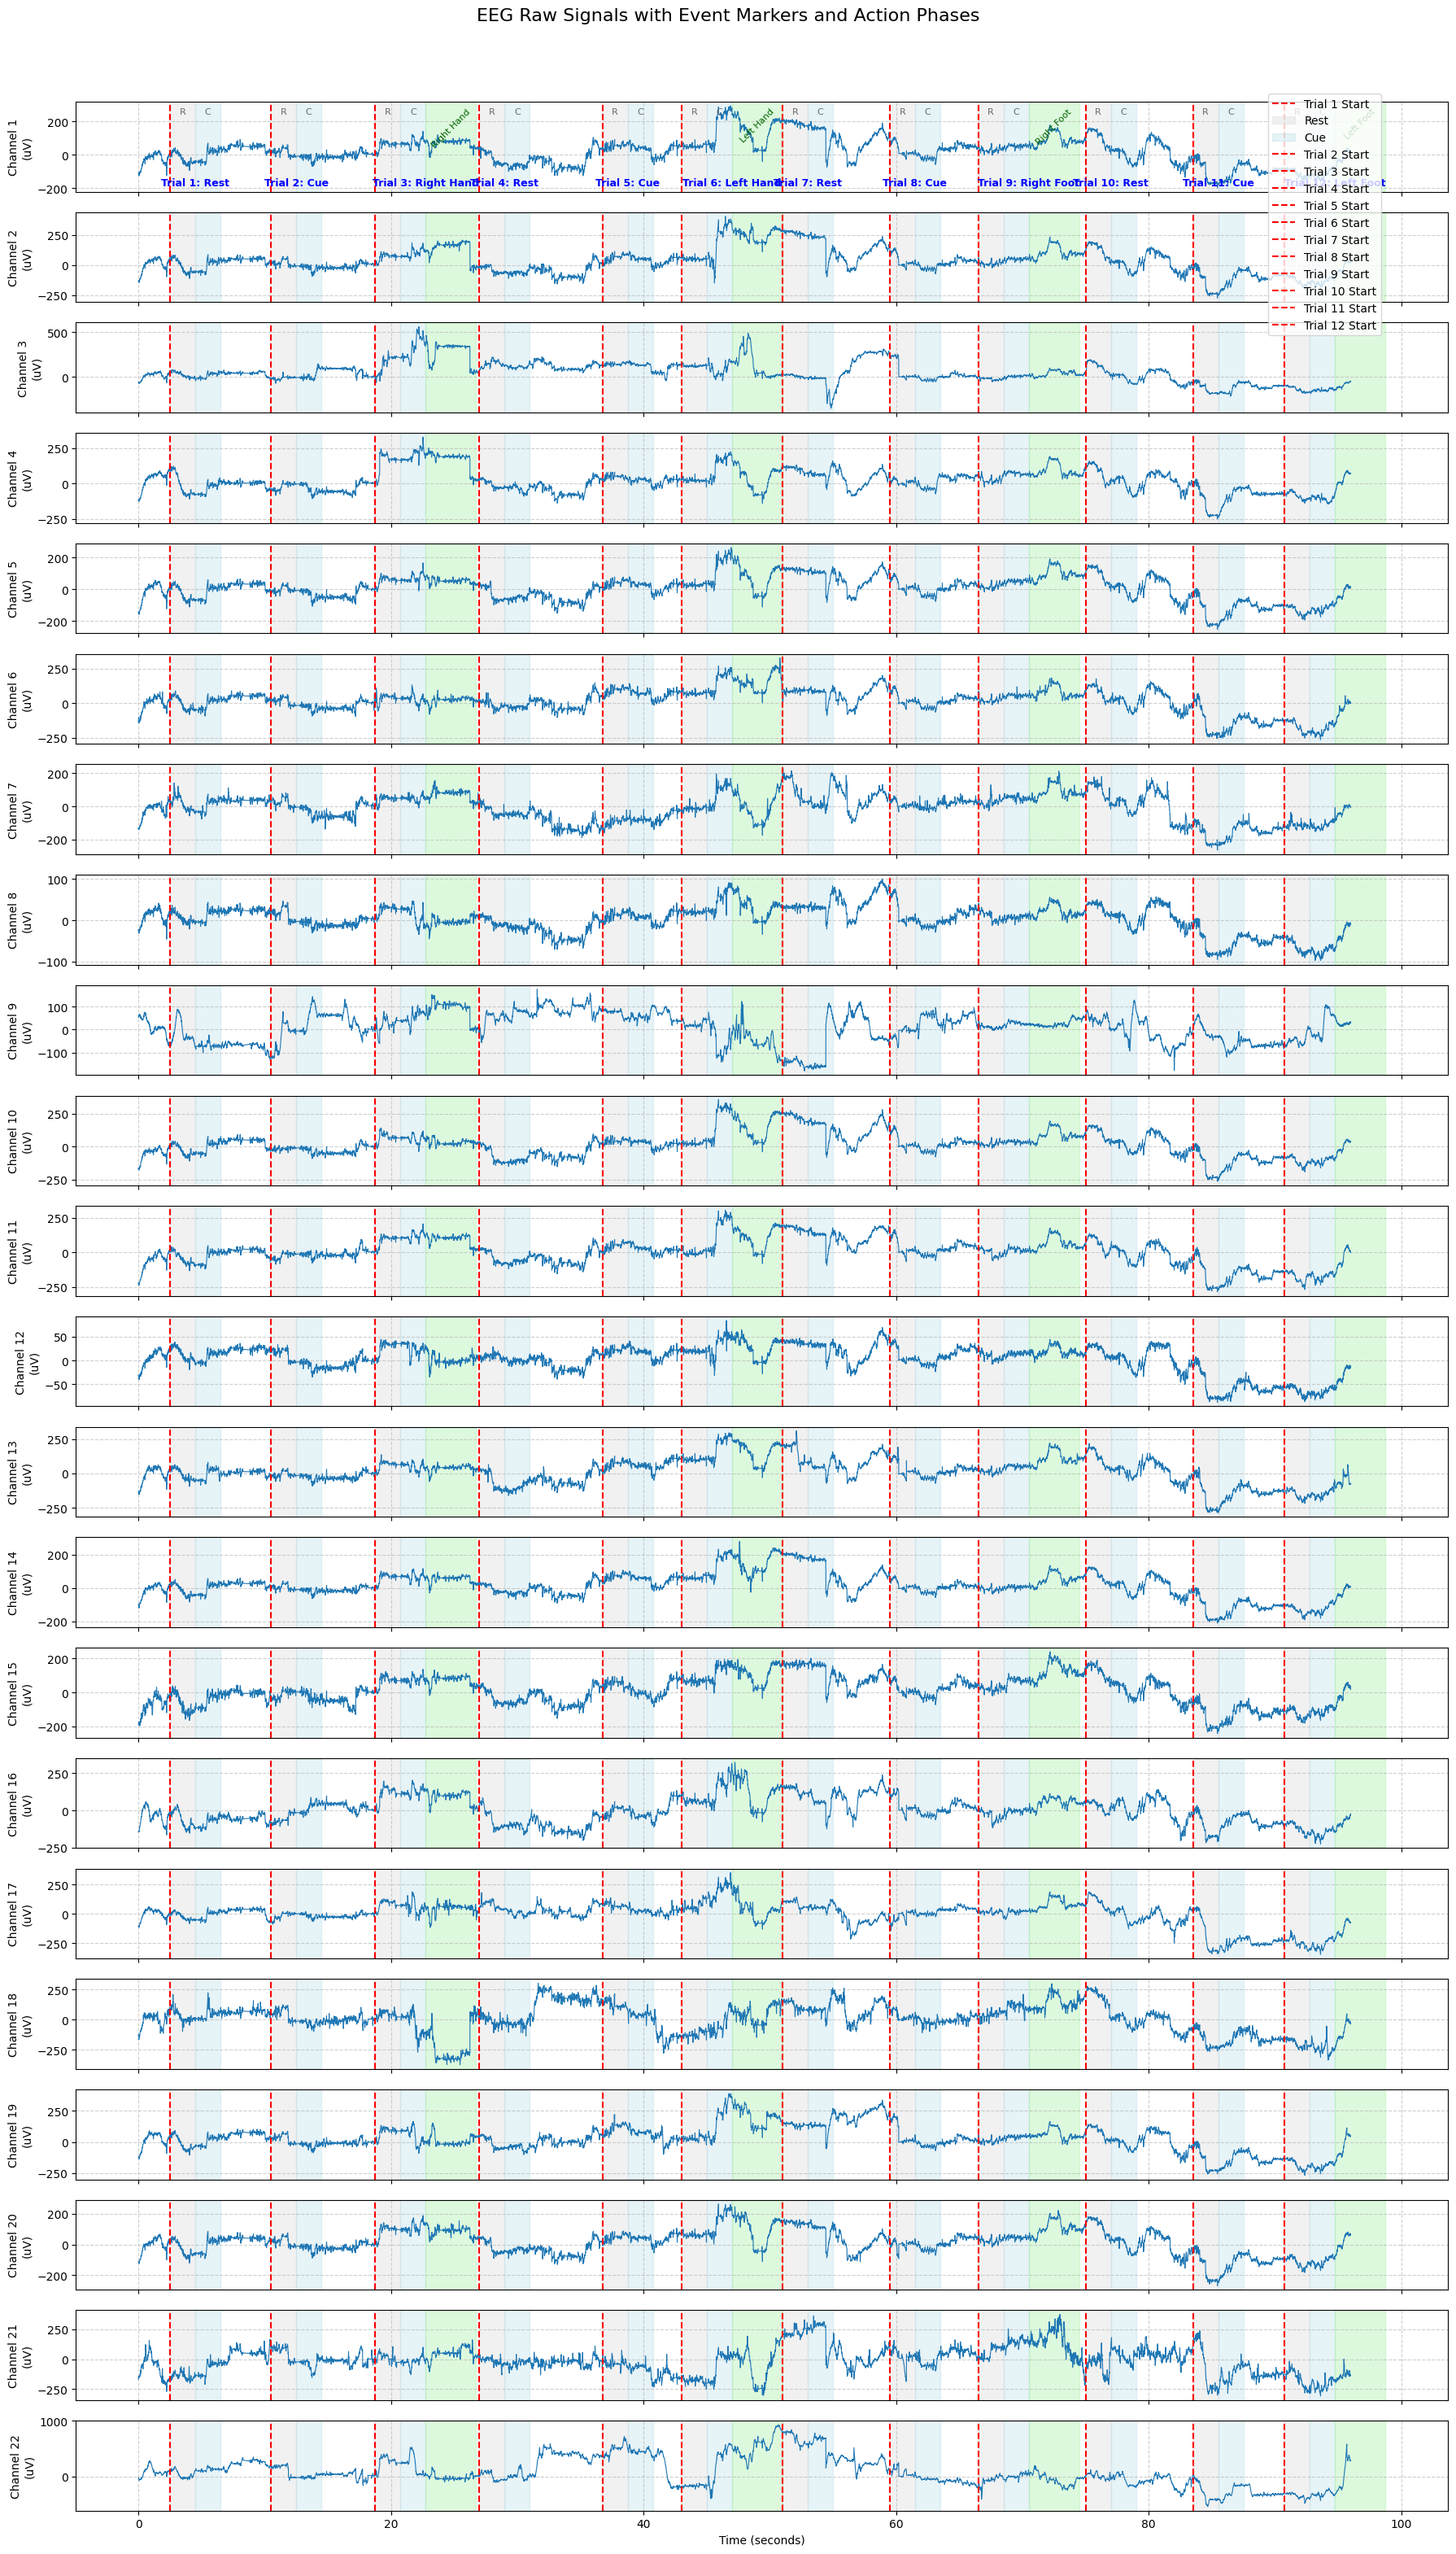

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import numpy as np

def visualize_eeg_data(raw_signal_path, session_setup_path, action_label_path, event_timestamp_path, sfreq=128):

    # 1. Load Raw EEG Signals
    try:
        eeg_df = pd.read_csv(raw_signal_path)
        # Giả sử cột đầu tiên là thời gian hoặc chỉ số, và các cột còn lại là kênh EEG.
        # Nếu cột đầu tiên là chỉ số, chúng ta có thể loại bỏ nó hoặc sử dụng làm index.
        # Để đơn giản, ta giả định tất cả các cột đều là kênh EEG.
        # Nếu có cột 'Time' hoặc 'Sample', hãy loại bỏ nó hoặc đặt làm index
        if 'Time' in eeg_df.columns:
            eeg_df = eeg_df.drop(columns=['Time'])
        if 'Sample' in eeg_df.columns:
            eeg_df = eeg_df.drop(columns=['Sample'])
        # Đổi tên cột để dễ đọc hơn nếu tên cột là số hoặc không chuẩn
        # Nếu các cột đã là 'Channel_1', 'Channel_2', ... thì không cần đổi
        num_channels = eeg_df.shape[1]
        channel_names = [f'Channel {i+1}' for i in range(num_channels)]
        eeg_df.columns = channel_names

        print(f"Loaded EEG data with {num_channels} channels and {len(eeg_df)} samples.")

    except FileNotFoundError:
        print(f"Error: Raw Signals file not found at {raw_signal_path}")
        return
    except Exception as e:
        print(f"Error loading Raw Signals CSV: {e}")
        return

    # 2. Load Session Setup (duration of actions)
    try:
        with open(session_setup_path, 'r') as f:
            session_setup = json.load(f)
        duration_info = session_setup.get('duration', {})
        print(f"Loaded Session Setup: {duration_info}")
    except FileNotFoundError:
        print(f"Error: Session setup file not found at {session_setup_path}")
        return
    except json.JSONDecodeError as e:
        print(f"Error decoding Session setup JSON: {e}")
        return

    # 3. Load Action Labels
    try:
        with open(action_label_path, 'r') as f:
            action_labels_raw = f.read().splitlines()
        # Chuyển đổi nhãn từ số sang tên hành động nếu có mapping
        # Giả định mapping: 1->R, 2->C, 3->RH, 4->LH, 5->RF, 6->LF (dựa trên Run1_Action label.txt và Run1_Session setup.json)
        # Sẽ cần điều chỉnh mapping này nếu các nhãn số đại diện cho các hành động khác.
        label_mapping = {
            '1': 'Rest', # Dựa vào Run1_Session setup.json (Action.R)
            '2': 'Cue',  # Dựa vào Run1_Session setup.json (Action.C)
            '3': 'Right Hand', # Dựa vào Run1_Session setup.json (Action.RH)
            '4': 'Left Hand',  # Dựa vào Run1_Session setup.json (Action.LH)
            '5': 'Right Foot', # Dựa vào Run1_Session setup.json (Action.RF)
            '6': 'Left Foot'   # Dựa vào Run1_Session setup.json (Action.LF)
        }
        action_labels = [label_mapping.get(label.strip(), f'Unknown ({label.strip()})') for label in action_labels_raw if label.strip()]
        print(f"Loaded Action Labels: {action_labels}")
    except FileNotFoundError:
        print(f"Error: Action label file not found at {action_label_path}")
        return
    # 4. Load Event Timestamps
    try:
        with open(event_timestamp_path, 'r') as f:
            event_timestamps_raw = f.read().splitlines()
        event_timestamps = [int(ts.strip()) for ts in event_timestamps_raw if ts.strip()]
        print(f"Loaded Event Timestamps: {event_timestamps}")
    except FileNotFoundError:
        print(f"Error: Event timestamp file not found at {event_timestamp_path}")
        return
    # Create time array
    time = np.arange(len(eeg_df)) / sfreq

    # Visualize the data
    fig, axes = plt.subplots(nrows=num_channels, ncols=1, figsize=(18, num_channels * 1.5), sharex=True)
    if num_channels == 1: # Handle case with only one channel (axes will not be an array)
        axes = [axes]

    # Define phase durations in seconds based on your problem description and JSON
    # Assuming "Action.R" is Rest, "Action.C" is Cue, and others are Actions
    rest_duration_sec = duration_info.get('Action.R', 0)
    cue_duration_sec = duration_info.get('Action.C', 0)
    # The actual 'Action' phase duration is variable based on the specific action type (RH, LH, RF, LF)
    # For visualization, we'll use the duration of the *specific* action label.

    # Iterate through each channel and plot
    for i, channel_name in enumerate(channel_names):
        axes[i].plot(time, eeg_df[channel_name], lw=0.8)
        axes[i].set_ylabel(f'{channel_name}\n(uV)')
        axes[i].grid(True, linestyle='--', alpha=0.6)

        # Add event markers and action phase highlights
        for j, timestamp_sample in enumerate(event_timestamps):
            event_time = timestamp_sample / sfreq
            # Draw vertical line for event start
            axes[i].axvline(event_time, color='r', linestyle='--', lw=1.5, label=f'Trial {j+1} Start' if i == 0 else "")

            # Highlight phases (Rest, Cue, Action)
            if j < len(action_labels):
                current_action_label = action_labels[j]

                # Determine the duration of the "Action" phase for the current label
                action_phase_duration_sec = 0
                if current_action_label == 'Right Hand':
                    action_phase_duration_sec = duration_info.get('Action.RH', 0)
                elif current_action_label == 'Left Hand':
                    action_phase_duration_sec = duration_info.get('Action.LH', 0)
                elif current_action_label == 'Right Foot':
                    action_phase_duration_sec = duration_info.get('Action.RF', 0)
                elif current_action_label == 'Left Foot':
                    action_phase_duration_sec = duration_info.get('Action.LF', 0)
                # Add more conditions for other action types if they exist in your data

                # Plot Rest phase
                if rest_duration_sec > 0:
                    axes[i].axvspan(event_time, event_time + rest_duration_sec,
                                    color='lightgray', alpha=0.3, label='Rest' if i == 0 and j == 0 else "")
                    # Add text label for Rest
                    if i == 0:
                         axes[i].text(event_time + rest_duration_sec / 2, axes[i].get_ylim()[1] * 0.9, 'R',
                                     horizontalalignment='center', verticalalignment='top', fontsize=8, color='dimgray')

                # Plot Cue phase
                cue_start_time = event_time + rest_duration_sec
                if cue_duration_sec > 0:
                    axes[i].axvspan(cue_start_time, cue_start_time + cue_duration_sec,
                                    color='lightblue', alpha=0.3, label='Cue' if i == 0 and j == 0 else "")
                    # Add text label for Cue
                    if i == 0:
                        axes[i].text(cue_start_time + cue_duration_sec / 2, axes[i].get_ylim()[1] * 0.9, 'C',
                                     horizontalalignment='center', verticalalignment='top', fontsize=8, color='dimgray')

                # Plot Action phase
                action_start_time = cue_start_time + cue_duration_sec
                if action_phase_duration_sec > 0:
                    axes[i].axvspan(action_start_time, action_start_time + action_phase_duration_sec,
                                    color='lightgreen', alpha=0.3, label='Action' if i == 0 and j == 0 else "")
                    # Add text label for Action type
                    if i == 0:
                        axes[i].text(action_start_time + action_phase_duration_sec / 2, axes[i].get_ylim()[1] * 0.9,
                                     current_action_label, horizontalalignment='center', verticalalignment='top',
                                     fontsize=8, color='darkgreen', rotation=45)

                # Add overall trial label at the bottom of the first channel
                if i == 0:
                    trial_end_time = action_start_time + action_phase_duration_sec
                    # Position label to be visible and not overlap too much
                    label_x_pos = (event_time + trial_end_time) / 2
                    axes[i].text(label_x_pos, axes[i].get_ylim()[0] * 0.9,
                                 f'Trial {j+1}: {current_action_label}',
                                 horizontalalignment='center', verticalalignment='bottom',
                                 fontsize=9, color='blue', weight='bold')


    # Set common labels and title
    axes[-1].set_xlabel('Time (seconds)')
    fig.suptitle('EEG Raw Signals with Event Markers and Action Phases', fontsize=16)
    fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95)) # Adjust legend position
    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()

# --- Example Usage ---
# Ensure these file paths are correct relative to where your script is run
raw_signal_file = '/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/Run2_Raw Signals.csv'
session_setup_file = '/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/Run2_Session setup.json'
action_label_file = '/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/Run2_Action label.txt'
event_timestamp_file = '/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/Run2_Event timestamp.txt'

# Run the visualization
visualize_eeg_data(raw_signal_file, session_setup_file, action_label_file, event_timestamp_file)